In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


In [2]:
data = pd.read_csv("clean_data.csv")
data['Transaction_Time'] = pd.to_datetime(data['Transaction_Time'], format='%H:%M:%S')
data['Transaction_Hour'] = data['Transaction_Time'].dt.hour
data['Transaction_Date'] = pd.to_datetime(data['Transaction_Date'], format='%Y-%m-%d')

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 49866 entries, 0 to 49865
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Unnamed: 0                             49866 non-null  int64         
 1   Transaction_ID                         49866 non-null  float64       
 2   Customer_ID                            49866 non-null  float64       
 3   Transaction_Amount (in Million)        49866 non-null  float64       
 4   Transaction_Time                       49866 non-null  datetime64[us]
 5   Transaction_Date                       49866 non-null  datetime64[us]
 6   Transaction_Type                       49866 non-null  str           
 7   Merchant_Category                      49866 non-null  str           
 8   Transaction_Location                   49866 non-null  str           
 9   Customer_Home_Location                 49866 non-null  str           
 1

In [3]:
data.head()

,Unnamed: 0,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Is_Fraud,Transaction_Hour
0,0,431438.0,24239.0,6.0,1900-01-01 10:54:00,2025-03-08,POS,ATM,Singapore,Lahore,...,17.0,2.0,4.0,1,1,0.0,0,1.0,0,10
1,1,902451.0,77250.0,9.0,1900-01-01 19:23:00,2025-01-17,ATM,ATM,Singapore,Lahore,...,9.0,5.0,8.0,1,1,1.0,0,1.0,0,19
2,2,223410.0,34294.0,3.0,1900-01-01 10:20:00,2025-04-30,POS,Electronics,Faisalabad,Faisalabad,...,18.0,5.0,8.0,1,0,0.0,1,1.0,0,10
3,3,145626.0,92041.0,1.0,1900-01-01 14:11:00,2025-02-21,Online,Grocery,London,Karachi,...,18.0,5.0,1.0,0,1,2.0,1,1.0,0,14
4,4,414637.0,71578.0,1.0,1900-01-01 04:12:00,2025-04-11,Online,Electronics,Singapore,Islamabad,...,18.0,4.0,3.0,0,1,1.0,0,1.0,0,4


## Data Cleaning & Preparation

In [4]:
binary_features = ['Is_New_Merchant', 'Is_International_Transaction', 'Unusual_Time_Transaction']
categorical_features = ['Card_Type', 'Merchant_Category', 'Transaction_Type']
numeric_features = [
    'Transaction_Amount (in Million)', 'Previous_Fraud_Count', 'Account_Balance (in Million)',
    'Distance_From_Home', 'Daily_Transaction_Count', 'Weekly_Transaction_Count',
    'Avg_Transaction_Amount (in Million)', 'Max_Transaction_Last_24h (in Million)', 'Failed_Transaction_Count',
    'Transaction_Hour'
]

keep_cols = binary_features + categorical_features + numeric_features + ['Is_Fraud']

data_cleaned = data[keep_cols].copy()

data_cleaned.head()


,Is_New_Merchant,Is_International_Transaction,Unusual_Time_Transaction,Card_Type,Merchant_Category,Transaction_Type,Transaction_Amount (in Million),Previous_Fraud_Count,Account_Balance (in Million),Distance_From_Home,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Transaction_Hour,Is_Fraud
0,1,1,0,Credit,ATM,POS,6.0,1.0,30.0,466.0,4.0,17.0,2.0,4.0,0.0,10,0
1,1,1,0,Credit,ATM,ATM,9.0,1.0,4.0,215.0,4.0,9.0,5.0,8.0,1.0,19,0
2,0,1,1,Debit,Electronics,POS,3.0,1.0,38.0,216.0,5.0,18.0,5.0,8.0,0.0,10,0
3,1,0,1,Debit,Grocery,Online,1.0,1.0,22.0,408.0,6.0,18.0,5.0,1.0,2.0,14,0
4,1,0,0,Debit,Electronics,Online,1.0,1.0,10.0,209.0,3.0,18.0,4.0,3.0,1.0,4,0


In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bin', OneHotEncoder(drop='if_binary'), binary_features)
    ])

clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', DecisionTreeClassifier(max_depth=4))])

In [6]:
X = data_cleaned.drop(columns=['Is_Fraud'])
y = data_cleaned['Is_Fraud']

target_names = ['No Fraud', "Fraud"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nTarget names:", target_names)
print("\nClass counts:")
print(y.value_counts().sort_index())

Feature matrix shape: (49866, 16)
Target vector shape: (49866,)

Target names: ['No Fraud', 'Fraud']

Class counts:
Is_Fraud
0    47449
1     2417
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (37399, 16)
Test set shape: (12467, 16)


## Helper Functions

In [8]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results = {
        "model": model_name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    }

    if hasattr(model, "predict_proba"):
        test_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, test_proba)
        roc_auc = auc(fpr, tpr)
        results["roc_auc"] = roc_auc
    else:
        results["roc_auc"] = np.nan

    return model, results


def plot_roc_curves(curves_dict):
    fig, ax = plt.subplots()
    for name, (fpr, tpr, roc_auc) in curves_dict.items():
        ax.plot(fpr, tpr, label=f"{name}  AUC={roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC curves on the test set")
    ax.legend()
    plt.show()


def plot_decision_boundary(model, X, y, title, feature_names):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots()
    ax.contourf(xx, yy, Z, alpha=0.25)

    for cls, label in zip([0, 1], ["malignant", "benign"]):
        mask = y == cls
        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            label=label,
            alpha=0.8
        )

    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_title(title)
    ax.legend()
    plt.show()

## Base Model

In [9]:
clf.fit(X_train, y_train)
clf, tree_results = evaluate_classifier(clf, X_train, X_test, y_train, y_test, "Decision Tree")
pd.DataFrame([tree_results])

,model,train_accuracy,test_accuracy,roc_auc
0,Decision Tree,0.951523,0.951552,0.601789


              precision    recall  f1-score   support

    No Fraud       0.95      1.00      0.98     11863
       Fraud       0.00      0.00      0.00       604

    accuracy                           0.95     12467
   macro avg       0.48      0.50      0.49     12467
weighted avg       0.91      0.95      0.93     12467



/Users/amiebinan/Desktop/WPI/Y25-26/D26/DATA SCIENCE/Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/amiebinan/Desktop/WPI/Y25-26/D26/DATA SCIENCE/Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/amiebinan/Desktop/WPI/Y25-26/D26/DATA SCIENCE/Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

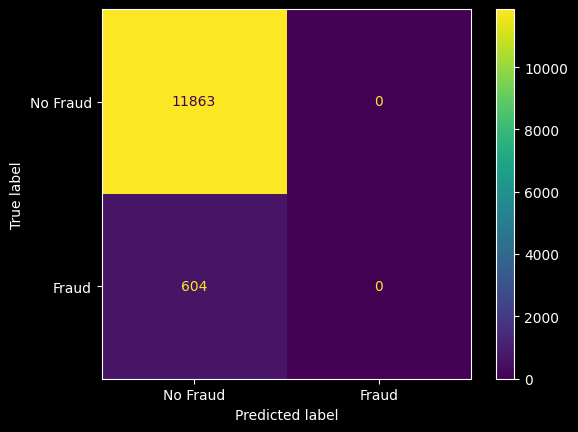

In [10]:
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Fraud", "Fraud"]).plot()

print(classification_report(y_test, y_pred, target_names=target_names))

## Model Tweaking

### Behavioral Inputs

In [11]:
behavioral_data = data.copy()

# Timing of Transactions
behavioral_data = behavioral_data.sort_values(['Customer_ID', 'Transaction_Date', 'Transaction_Time'])
behavioral_data['Time_Diff'] = behavioral_data.groupby('Customer_ID')['Transaction_Time'].diff()
behavioral_data['Min_Since_Last_Tx'] = behavioral_data['Time_Diff'].dt.total_seconds() / 60
behavioral_data['Min_Since_Last_Tx'] = behavioral_data['Min_Since_Last_Tx'].fillna(999)
behavioral_data['Transactions_Today'] = behavioral_data.groupby(['Customer_ID', 'Transaction_Date']).cumcount() + 1

# Spending Trends
behavioral_data['Customer_Hist_Avg'] = (behavioral_data.groupby('Customer_ID')['Transaction_Amount (in Million)']
                                        .transform(lambda x: x.expanding().mean()))
behavioral_data['Spend_to_Avg_Ratio'] = (behavioral_data['Transaction_Amount (in Million)']
                                         / (behavioral_data['Customer_Hist_Avg'] + 1e-9))
behavioral_data['Customer_Hist_Max'] = (behavioral_data.groupby('Customer_ID')['Transaction_Amount (in Million)']
                                        .transform(lambda x: x.expanding().max()))
behavioral_data['Is_New_Spend_Record'] = (behavioral_data['Transaction_Amount (in Million)']
                                          >= behavioral_data['Customer_Hist_Max']).astype(int)

In [47]:
behavioral_data.head(100)
# behavioral_data.to_csv('behavioral_data.csv')
# behavioral_data.columns

In [13]:
new_binary_features = ['Is_New_Merchant', 'Is_International_Transaction', 'Unusual_Time_Transaction', 'Is_New_Spend_Record']
new_categorical_features = ['Card_Type', 'Merchant_Category', 'Transaction_Type']
new_numeric_features = [
    'Transaction_Amount (in Million)', 'Previous_Fraud_Count',
    'Distance_From_Home', 'Max_Transaction_Last_24h (in Million)', 'Failed_Transaction_Count',
    'Transaction_Hour', 'Spend_to_Avg_Ratio', 'Transactions_Today', 'Min_Since_Last_Tx', 'Customer_Hist_Avg',
]

new_keep_cols = new_binary_features + new_categorical_features + new_numeric_features + ['Is_Fraud', 'Customer_ID']

new_data_cleaned = behavioral_data[new_keep_cols].copy()

new_data_cleaned.head()

,Is_New_Merchant,Is_International_Transaction,Unusual_Time_Transaction,Is_New_Spend_Record,Card_Type,Merchant_Category,Transaction_Type,Transaction_Amount (in Million),Previous_Fraud_Count,Distance_From_Home,Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Transaction_Hour,Spend_to_Avg_Ratio,Transactions_Today,Min_Since_Last_Tx,Customer_Hist_Avg,Is_Fraud,Customer_ID
16861,0,0,0,1,Credit,Electronics,ATM,9.0,0.0,562.0,9.0,2.0,15,1.000000,1,999.0,9.0,0,10005.0
12912,0,1,0,1,Debit,Grocery,POS,7.0,0.0,364.0,3.0,2.0,20,1.000000,1,999.0,7.0,0,10009.0
23195,0,0,1,0,Debit,Restaurant,Online,4.0,1.0,549.0,7.0,0.0,22,0.727273,1,126.0,5.5,0,10009.0
12961,0,0,0,0,Debit,Fuel,Online,4.0,1.0,462.0,5.0,1.0,6,0.800000,1,-993.0,5.0,0,10009.0
16271,1,1,0,1,Credit,ATM,POS,9.0,1.0,62.0,6.0,1.0,11,1.000000,1,999.0,9.0,0,10013.0


In [35]:
new_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), new_numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), new_categorical_features),
        ('bin', OneHotEncoder(drop='if_binary'), new_binary_features)
    ]
)

# update classifier step in the pipeline
new_clf = Pipeline(steps=[
    ('preprocessor', new_preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=6,             # increase depth slightly
        class_weight='balanced', # forces model to care about fraud
        random_state=42
    ))
])

In [36]:
new_X = new_data_cleaned.drop(columns=['Is_Fraud'])
new_y = new_data_cleaned['Is_Fraud']

target_names = ['No Fraud', "Fraud"]

print("Feature matrix shape:", new_X.shape)
print("Target vector shape:", new_y.shape)
print("\nTarget names:", target_names)
print("\nClass counts:")
print(new_y.value_counts().sort_index())

Feature matrix shape: (49866, 18)
Target vector shape: (49866,)

Target names: ['No Fraud', 'Fraud']

Class counts:
Is_Fraud
0    47449
1     2417
Name: count, dtype: int64


In [42]:
# the same customer should consistently appear in training or test data, not both
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

# split group by customer
train_idx, test_idx = next(gss.split(new_X, new_y, groups=behavioral_data['Customer_ID']))
X_train_grouped = new_X.iloc[train_idx]
y_train_grouped = new_y.iloc[train_idx]
X_test_grouped = new_X.iloc[test_idx]
y_test_grouped = new_y.iloc[test_idx]

# don't need customer id
X_train_final = X_train_grouped.drop(columns=['Customer_ID'])
X_test_final = X_test_grouped.drop(columns=['Customer_ID'])

print("Training set shape:", X_train_final.shape)
print("Test set shape:", X_test_final.shape)

Training set shape: (37375, 17)
Test set shape: (12491, 17)


In [43]:
new_clf.fit(X_train_final, y_train_grouped)
new_clf, new_tree_results = evaluate_classifier(
    new_clf, X_train_final, X_test_final, y_train_grouped, y_test_grouped,
    "Decision Tree"
)
pd.DataFrame([new_tree_results])

,model,train_accuracy,test_accuracy,roc_auc
0,Decision Tree,0.437913,0.429429,0.588406


              precision    recall  f1-score   support

    No Fraud       0.97      0.41      0.58     11867
       Fraud       0.06      0.72      0.11       624

    accuracy                           0.43     12491
   macro avg       0.51      0.57      0.35     12491
weighted avg       0.92      0.43      0.56     12491



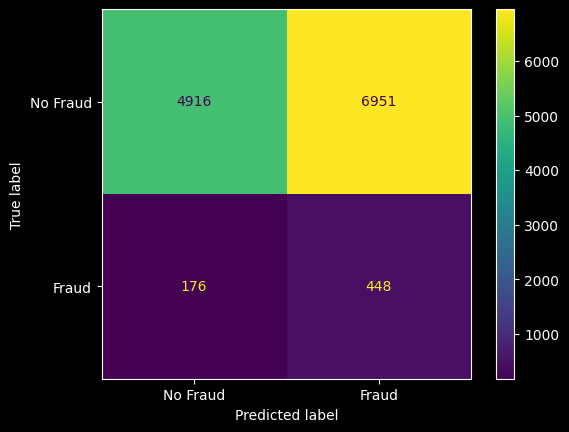

In [40]:
new_y_pred = new_clf.predict(X_test_final)

new_cm = confusion_matrix(y_test_grouped, new_y_pred)
ConfusionMatrixDisplay(new_cm, display_labels=["No Fraud", "Fraud"]).plot()

print(classification_report(y_test_grouped, new_y_pred, target_names=target_names))

## Random Forest

In [45]:
rf_clf = Pipeline(steps=[
    ('preprocessor', new_preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,        # 100 trees working together
        max_depth=12,            # More depth is okay here because trees are averaged
        min_samples_leaf=50,     # Keeps the trees from getting too "paranoid"
        class_weight='balanced', # Still essential for catching fraud
        random_state=42,
        n_jobs=-1                # Uses all your CPU cores for speed
    ))
])

# Fit the model
rf_clf.fit(X_train_final, y_train_grouped)

# Evaluate
rf_clf, rf_results = evaluate_classifier(
    rf_clf, X_train_final, X_test_final, y_train_grouped, y_test_grouped,
    "Random Forest"
)
pd.DataFrame([rf_results])

,model,train_accuracy,test_accuracy,roc_auc
0,Random Forest,0.797431,0.759107,0.597109


              precision    recall  f1-score   support

    No Fraud       0.96      0.78      0.86     11867
       Fraud       0.07      0.30      0.11       624

    accuracy                           0.76     12491
   macro avg       0.51      0.54      0.49     12491
weighted avg       0.91      0.76      0.82     12491



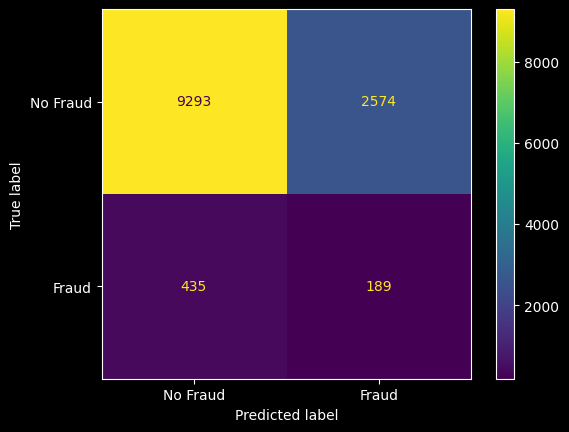

In [46]:
rf_y_pred = rf_clf.predict(X_test_final)

rf_cm = confusion_matrix(y_test_grouped, rf_y_pred)
ConfusionMatrixDisplay(rf_cm, display_labels=["No Fraud", "Fraud"]).plot()

print(classification_report(y_test_grouped, rf_y_pred, target_names=target_names))